# Tutorial: Adaptive-SPORES x PyPSA

In [1]:
import yaml
import pypsa

from mga4all.examples import create_pypsa_network

import pandas as pd

## 1. Load example PyPSA model

In [2]:
# Load example PyPSA model that the config refers to
n = create_pypsa_network()

INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'SciGrid-DE' has buses, carriers, generators, lines, loads, storage_units, transformers


In [3]:
# Set the desired solver options
pypsa.options.params.optimize.solver_name = "gurobi"
pypsa.options.params.optimize.solver_options = {
    'Method': 2,  # Use the barrier algorithm
    'Crossover': 0,
}

In [4]:
# Find cost-optimal solution
n.optimize(log_to_console=False);

/tmp/ipykernel_57375/2238090962.py:2: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(log_to_console=False);
Index(['line'], dtype='object', name='name')
Index(['line'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - Method: 2
 - Crossover: 0
 - log_to_console: False
INFO:linopy.io: Writing time: 0.13s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2762135


INFO:gurobipy:Set parameter LicenseID to value 2762135


...

INFO:gurobipy:Set parameter Method to value 2


Set parameter Crossover to value 0


INFO:gurobipy:Set parameter Crossover to value 0


Set parameter LogToConsole to value 0


INFO:gurobipy:Set parameter LogToConsole to value 0
INFO:gurobipy:Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Linux Mint 22.2")
INFO:gurobipy:
INFO:gurobipy:CPU model: Intel(R) Core(TM) i5-6300U CPU @ 2.40GHz, instruction set [SSE2|AVX|AVX2]
INFO:gurobipy:Thread count: 2 physical cores, 4 logical processors, using up to 4 threads
INFO:gurobipy:
INFO:gurobipy:Non-default parameters:
INFO:gurobipy:Method  2
INFO:gurobipy:Crossover  0
INFO:gurobipy:LogToConsole  0
INFO:gurobipy:
INFO:gurobipy:Optimize a model with 688 rows, 296 columns and 1324 nonzeros (Min)
INFO:gurobipy:Model fingerprint: 0xd41ae2e6
INFO:gurobipy:Model has 8 linear objective coefficients
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [4e-02, 5e+00]
INFO:gurobipy:  Objective range  [4e+02, 2e+03]
INFO:gurobipy:  Bounds range     [0e+00, 0e+00]
INFO:gurobipy:  RHS range        [2e+02, 1e+03]
INFO:gurobipy:
INFO:gurobipy:Presolve removed 124 rows and 332 columns
INFO:gurobipy:Preso

## 2. Generate alternative solutions with SPORES MGA (simple diversificaton)

### 2.1 Load and check MGA configuration

In [5]:
from mga4all.validate import SPORESConfig

# Load configuration file
with open("../../configs/test_config_spores_diversify_only.yaml") as yf:
    test_config = SPORESConfig.model_validate(yaml.safe_load(yf))

In [6]:
# Check that it reflects the desired setup
test_config

SPORESConfig(config_name='spores', model_interface='pypsa', alternatives=5, cost_slack=0.2, spatially_explicit=True, diversification_coefficient=1, diversified_technologies=['wind', 'solar', 'gas', 'battery'], intensification_coefficient=0, intensified_technologies=[])

### 2.2 Import algorithm and run (with the 'adaptive' parameter set to True!)

In [7]:
from mga4all.mga_spores import spores_algorithm

In [8]:
mga_alternatives, mga_spatial_alternatives, mga_weights, shannon = spores_algorithm(test_config, n, adaptive=True)

Index(['line'], dtype='object', name='name')
Index(['line'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - Method: 2
 - Crossover: 0
 - log_to_console: False


Technologies [] not found in the model


INFO:linopy.io: Writing time: 0.14s


Set parameter Username


INFO:gurobipy:Set parameter Username


...

INFO:gurobipy:Set parameter Method to value 2


Set parameter Crossover to value 0


INFO:gurobipy:Set parameter Crossover to value 0


Set parameter LogToConsole to value 0


INFO:gurobipy:Set parameter LogToConsole to value 0
INFO:gurobipy:Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Linux Mint 22.2")
INFO:gurobipy:
INFO:gurobipy:CPU model: Intel(R) Core(TM) i5-6300U CPU @ 2.40GHz, instruction set [SSE2|AVX|AVX2]
INFO:gurobipy:Thread count: 2 physical cores, 4 logical processors, using up to 4 threads
INFO:gurobipy:
INFO:gurobipy:Non-default parameters:
INFO:gurobipy:Method  2
INFO:gurobipy:Crossover  0
INFO:gurobipy:LogToConsole  0
INFO:gurobipy:
INFO:gurobipy:Optimize a model with 689 rows, 296 columns and 1332 nonzeros (Min)
INFO:gurobipy:Model fingerprint: 0x3db5ff08
INFO:gurobipy:Model has 7 linear objective coefficients
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [4e-02, 2e+03]
INFO:gurobipy:  Objective range  [4e-02, 1e+00]
INFO:gurobipy:  Bounds range     [0e+00, 0e+00]
INFO:gurobipy:  RHS range        [2e+02, 7e+05]
INFO:gurobipy:
INFO:gurobipy:Presolve removed 124 rows and 334 columns
INFO:gurobipy:Preso

### 2.3 Inspect the alternatives

In [9]:
mga_total_capacities = pd.concat((
    pd.DataFrame(mga_alternatives[x]).fillna(0).round(2).sum(axis=1) for x in mga_alternatives
), axis=1)

mga_spatial_capacities = pd.concat((
    pd.DataFrame(mga_spatial_alternatives[x]).fillna(0).round(2).sum(axis=1) for x in mga_alternatives
), axis=1)

<Axes: >

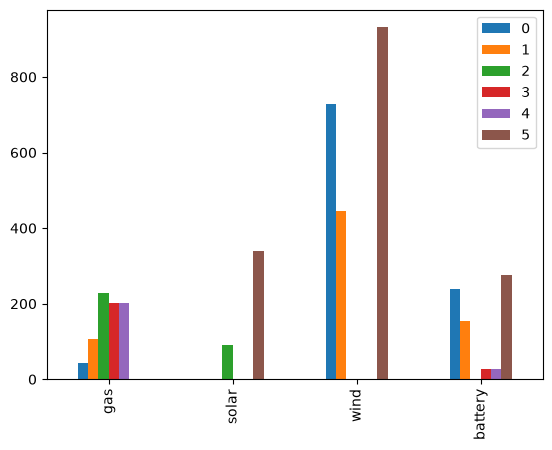

In [10]:
mga_total_capacities.plot.bar()

<Axes: >

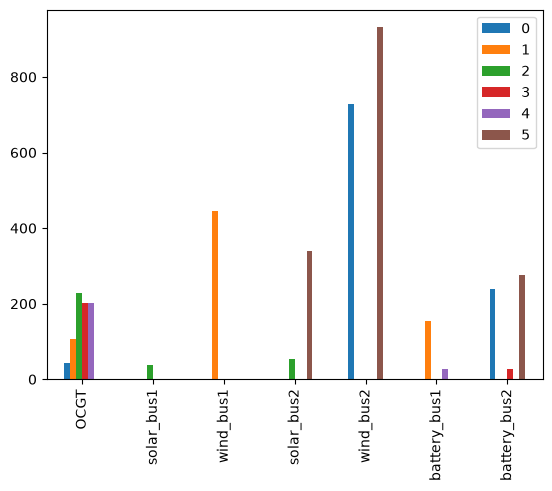

In [11]:
mga_spatial_capacities.plot.bar()

In [12]:
mga_weights = pd.concat((
    pd.DataFrame(mga_weights[x]).fillna(0).round(2).sum(axis=1) for x in mga_weights
), axis=1)
mga_weights

,0,1,2,3,4,5
OCGT,0,0.06,0.20,0.75,0.93,0.96
solar_bus1,0,0.00,0.00,0.10,0.06,-0.05
wind_bus1,0,0.00,0.65,0.42,0.22,0.07
solar_bus2,0,0.00,0.00,0.15,0.08,-0.18
wind_bus2,0,0.95,0.67,0.43,0.23,0.04
battery_bus1,0,0.00,0.22,0.15,0.08,0.10
battery_bus2,0,0.31,0.22,0.14,0.14,0.13


In [13]:
print("The Shannon index for diversity is: {}".format(round(shannon,2)))

np.float64(0.41)

## 3. Generate alternative solutions with SPORES MGA (diversificaton + intensification)
This time, we first identify an extreme of the solution space (highest solar capacity while lowest wind capacity), then generate diversity around it. This is achieved via the 'intensification' feature of SPORES.

### 3.1 Load and check new MGA configuration

In [14]:
with open("../../configs/test_config_spores_diversify_intensify.yaml") as yf:
    test_config = SPORESConfig.model_validate(yaml.safe_load(yf))
test_config

SPORESConfig(config_name='spores', model_interface='pypsa', alternatives=5, cost_slack=0.2, spatially_explicit=True, diversification_coefficient=1, diversified_technologies=['wind', 'solar', 'gas', 'battery'], intensification_coefficient=[1, -1], intensified_technologies=['wind', 'solar'])

### 3.2 Run the SPORES algorithm with the new configuration

In [15]:
mga_alternatives, mga_spatial_alternatives, mga_weights, shannon = spores_algorithm(test_config, n, adaptive=True)

Index(['line'], dtype='object', name='name')
Index(['line'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - Method: 2
 - Crossover: 0
 - log_to_console: False


Technologies [] not found in the model


INFO:linopy.io: Writing time: 0.12s


Set parameter Username


INFO:gurobipy:Set parameter Username


...

INFO:gurobipy:Set parameter Method to value 2


Set parameter Crossover to value 0


INFO:gurobipy:Set parameter Crossover to value 0


Set parameter LogToConsole to value 0


INFO:gurobipy:Set parameter LogToConsole to value 0
INFO:gurobipy:Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Linux Mint 22.2")
INFO:gurobipy:
INFO:gurobipy:CPU model: Intel(R) Core(TM) i5-6300U CPU @ 2.40GHz, instruction set [SSE2|AVX|AVX2]
INFO:gurobipy:Thread count: 2 physical cores, 4 logical processors, using up to 4 threads
INFO:gurobipy:
INFO:gurobipy:Non-default parameters:
INFO:gurobipy:Method  2
INFO:gurobipy:Crossover  0
INFO:gurobipy:LogToConsole  0
INFO:gurobipy:
INFO:gurobipy:Optimize a model with 689 rows, 296 columns and 1332 nonzeros (Min)
INFO:gurobipy:Model fingerprint: 0xb18ba50d
INFO:gurobipy:Model has 7 linear objective coefficients
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [4e-02, 2e+03]
INFO:gurobipy:  Objective range  [1e-02, 6e-01]
INFO:gurobipy:  Bounds range     [0e+00, 0e+00]
INFO:gurobipy:  RHS range        [2e+02, 7e+05]
INFO:gurobipy:
INFO:gurobipy:Presolve removed 124 rows and 334 columns
INFO:gurobipy:Preso

### 3.3 Inspect the new alternatives

In [16]:
mga_total_capacities = pd.concat((
    pd.DataFrame(mga_alternatives[x]).fillna(0).round(2).sum(axis=1) for x in mga_alternatives
), axis=1)

mga_spatial_capacities = pd.concat((
    pd.DataFrame(mga_spatial_alternatives[x]).fillna(0).round(2).sum(axis=1) for x in mga_alternatives
), axis=1)

<Axes: >

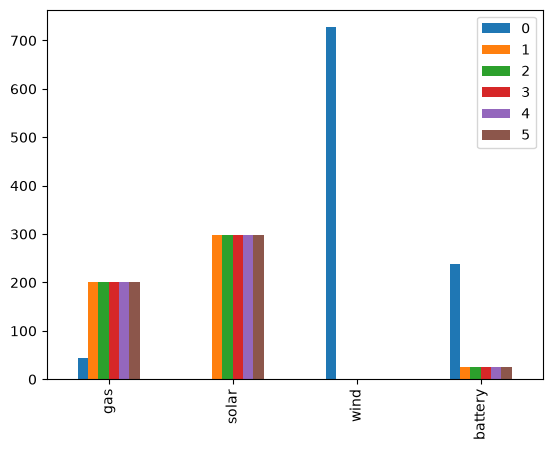

In [17]:
mga_total_capacities.plot.bar()

<Axes: >

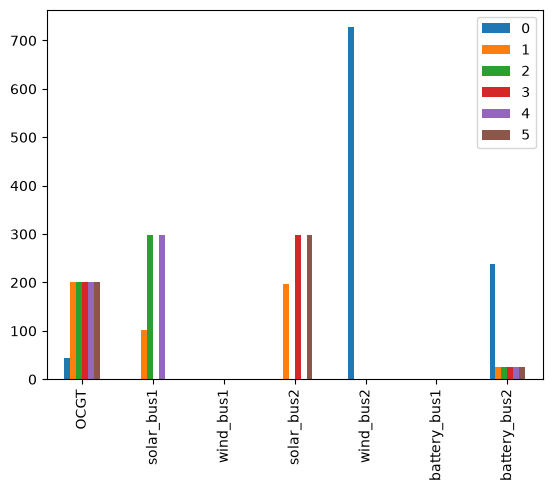

In [18]:
mga_spatial_capacities.plot.bar()

In [19]:
mga_weights = pd.concat((
    pd.DataFrame(mga_weights[x]).fillna(0).round(2).sum(axis=1) for x in mga_weights
), axis=1)
mga_weights

,0,1,2,3,4,5
OCGT,0,0.0,0.39,0.37,-0.41,0.14
solar_bus1,0,-0.5,-0.38,-0.20,-0.58,-0.21
wind_bus1,0,0.5,0.58,0.75,0.34,0.59
solar_bus2,0,-0.5,-0.20,-0.36,0.15,-0.40
wind_bus2,0,0.5,0.58,0.36,0.46,0.59
battery_bus1,0,0.0,0.00,0.00,-0.21,-0.01
battery_bus2,0,0.0,0.05,0.05,0.31,0.27


In [22]:
print("The Shannon index for diversity is: {}".format(round(shannon,2)))

The Shannon index for diversity is: 0.22
